In [1]:
!pip install torch torchvision torchaudio


In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())


2.11.0+cpu
CUDA available: False


In [3]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


2.11.0+cpu
CUDA available: False
Device name: CPU only


In [4]:
import torch
import torch.nn as nn

# Define a simple feed-forward network
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Example: create model
model = FeedForwardNN(input_size=10, hidden_size=32, output_size=2)
print(model)


FeedForwardNN(
  (fc1): Linear(in_features=10, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)


In [5]:
import torch.optim as optim

# Loss function (for binary classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Sample data: 100 examples, each with 10 features
X = torch.randn(100, 10)
y = torch.randint(0, 2, (100,))  # binary labels (0 or 1)

# Combine into a dataset
dataset = TensorDataset(X, y)

# Create a DataLoader for batching
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


In [8]:
# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    for batch_X, batch_y in dataloader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/10], Loss: 0.6039
Epoch [2/10], Loss: 0.5635
Epoch [3/10], Loss: 0.8547
Epoch [4/10], Loss: 0.7470
Epoch [5/10], Loss: 0.6376
Epoch [6/10], Loss: 0.7311
Epoch [7/10], Loss: 0.9046
Epoch [8/10], Loss: 0.7151
Epoch [9/10], Loss: 0.6225
Epoch [10/10], Loss: 0.7197


In [9]:
# Switch to evaluation mode
model.eval()

# Disable gradient computation for testing
with torch.no_grad():
    sample_X, sample_y = next(iter(dataloader))
    outputs = model(sample_X)
    predicted = torch.argmax(outputs, dim=1)

print("Predicted labels:", predicted[:10])
print("Actual labels:", sample_y[:10])


Predicted labels: tensor([0, 0, 0, 0, 1, 0, 1, 0, 1, 0])
Actual labels: tensor([1, 1, 1, 1, 1, 0, 1, 1, 0, 1])


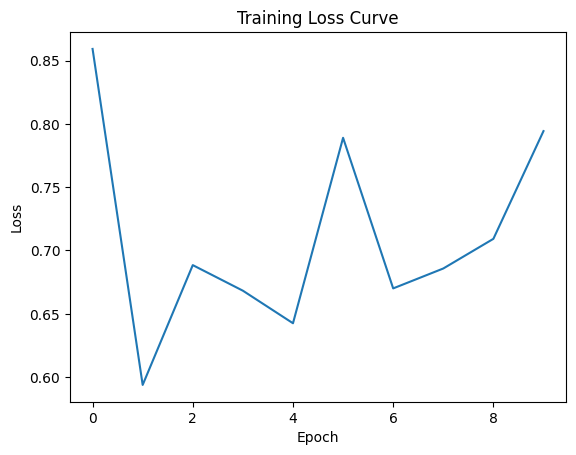

In [10]:
import matplotlib.pyplot as plt

# Example: store losses during training
losses = []

for epoch in range(num_epochs):
    for batch_X, batch_y in dataloader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    losses.append(loss.item())

plt.plot(range(num_epochs), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


In [11]:
# Save the trained model
torch.save(model.state_dict(), "feedforward_model.pth")
print("Model saved successfully!")


Model saved successfully!


In [12]:
# Load the model
loaded_model = FeedForwardNN(input_size=10, hidden_size=32, output_size=2)
loaded_model.load_state_dict(torch.load("feedforward_model.pth"))
loaded_model.eval()
print("Model loaded and ready for inference!")


Model loaded and ready for inference!
